#Part 2 — Baseline Regression Modeling
# Steel Industry Energy Consumption Dataset

0. SETUP & DATA UPLOAD

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
try:
    from google.colab import files
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]
except ImportError:
    csv_path = 'steel_industry_engineered.csv'

Saving steel_industry_engineered.csv to steel_industry_engineered.csv


In [4]:
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
display(df.head())

Shape: (35040, 17)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,DayOfWeek_Num,Month,Is_Weekend,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0,1,0,1.545117,0


1 & 2. PREP: DROP DATE + LEAKAGE COLUMNS

This step removes the `date` column (models can't use raw dates, and we already
extracted Hour/Month/etc. from it) and removes `High_Load` (because it was literally built from
`Usage_kWh`, so keeping it would let the model "cheat" by looking at the answer this is called
data leakage).

In [5]:
# High_Load leaks the target directly
model_df = df.drop(columns=['date', 'High_Load'])

3. ENCODE CATEGORICALS

This step Converts text categories (`WeekStatus`, `Day_of_week`, `Load_Type`) into
numeric columns the model can understand, using One-Hot Encoding (creating a separate 0/1 column
for each category). I chose One-Hot over Label Encoding because these categories have no natural
order (e.g. "Monday" isn't greater than "Tuesday") — Label Encoding would wrongly imply a ranking,
which especially confuses Linear/Ridge Regression models.

In [6]:
cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

X = model_df.drop(columns=['Usage_kWh'])
y = model_df['Usage_kWh']
print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (35040, 20)


4. TRAIN/TEST SPLIT

This step splits the data into a training set (80%) and a testing set (20%).
The model learns patterns from the training set, and we check how well it performs on the testing
set (data it has never seen). `random_state=42` just makes sure we get the same split every time.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5, 6 & 7. TRAIN 4 MODELS + METRICS + 5-FOLD CV

This step trains four different regression models (Linear Regression, Ridge
Regression, Decision Tree, Random Forest) on the training data, then tests each one on the
test set. For each model we calculate:
- MAE — average size of the prediction error (in kWh)
- RMSE — similar to MAE but penalizes big errors more
- R² — how much of the variation in usage the model explains (closer to 1 = better)

I also run 5-fold cross-validation, which retrains the model 5 times on different slices
of data to double-check that the results aren't just lucky from one particular split.


In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    cv_rmse_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    cv_rmse_mean = cv_rmse_scores.mean()

    results[name] = {'MAE': mae, 'Test_RMSE': rmse, 'R2': r2, 'CV_RMSE_mean': cv_rmse_mean}

    print(f"\n{name}")
    print(f"  MAE       : {mae:.4f}")
    print(f"  RMSE      : {rmse:.4f}")
    print(f"  R2        : {r2:.4f}")
    print(f"  CV RMSE   : {cv_rmse_mean:.4f} (5-fold)")

results_df = pd.DataFrame(results).T.sort_values('Test_RMSE')
display(results_df)


Linear Regression
  MAE       : 2.6339
  RMSE      : 4.1460
  R2        : 0.9849
  CV RMSE   : 4.5125 (5-fold)

Ridge Regression
  MAE       : 4.3604
  RMSE      : 6.2666
  R2        : 0.9655
  CV RMSE   : 6.2285 (5-fold)

Decision Tree
  MAE       : 0.5500
  RMSE      : 1.5182
  R2        : 0.9980
  CV RMSE   : 1.4899 (5-fold)

Random Forest
  MAE       : 0.3510
  RMSE      : 1.0532
  R2        : 0.9990
  CV RMSE   : 1.0191 (5-fold)


,MAE,Test_RMSE,R2,CV_RMSE_mean
Random Forest,0.350960,1.053154,0.999024,1.019127
Decision Tree,0.550021,1.518221,0.997972,1.489888
Linear Regression,2.633882,4.146028,0.984878,4.512538
Ridge Regression,4.360434,6.266551,0.965454,6.228522


8. BAR CHART — TEST RMSE COMPARISON

This step puts all four models' RMSE scores side by side in a bar chart so you can
instantly see which model made the smallest prediction errors (shorter bar = better model).

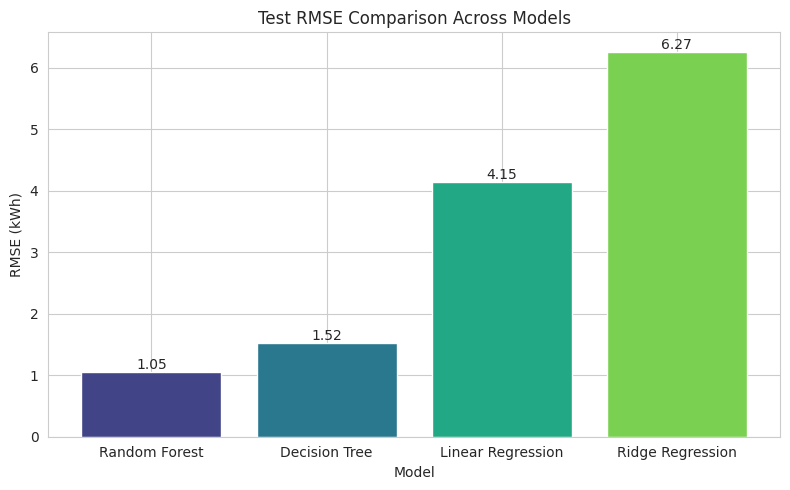

In [9]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df.index, results_df['Test_RMSE'], color=sns.color_palette('viridis', 4))
plt.title('Test RMSE Comparison Across Models')
plt.ylabel('RMSE (kWh)')
plt.xlabel('Model')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

9. PREDICTED VS ACTUAL — BEST MODEL

This step picks the model with the lowest test RMSE (the best performer), then
plots its predictions against the actual real values. The closer the dots sit to the red dashed
line (perfect prediction), the more accurate the model is.

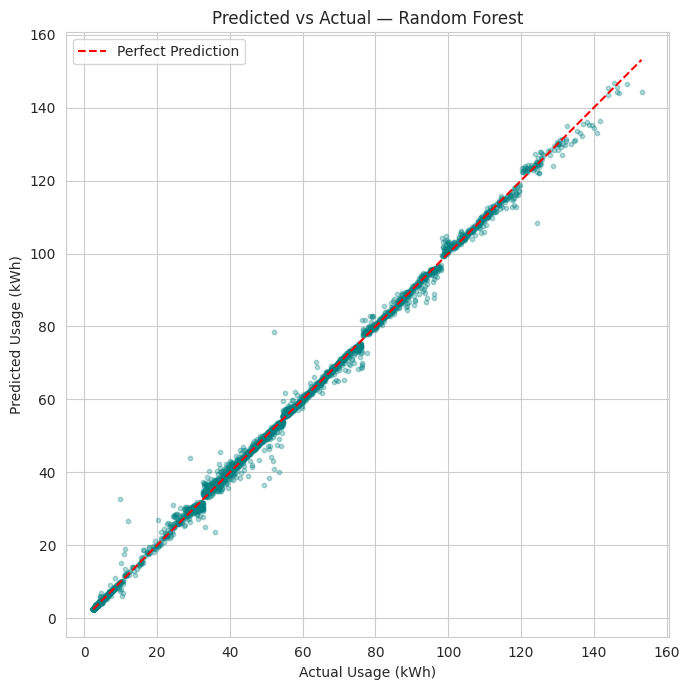

In [10]:
best_model_name = results_df['Test_RMSE'].idxmin()
best_preds = predictions[best_model_name]

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.3, s=10, color='teal')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.title(f'Predicted vs Actual — {best_model_name}')
plt.xlabel('Actual Usage (kWh)')
plt.ylabel('Predicted Usage (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE (Random Forest)

This step shows which features the Random Forest model relied on most
to make its predictions.

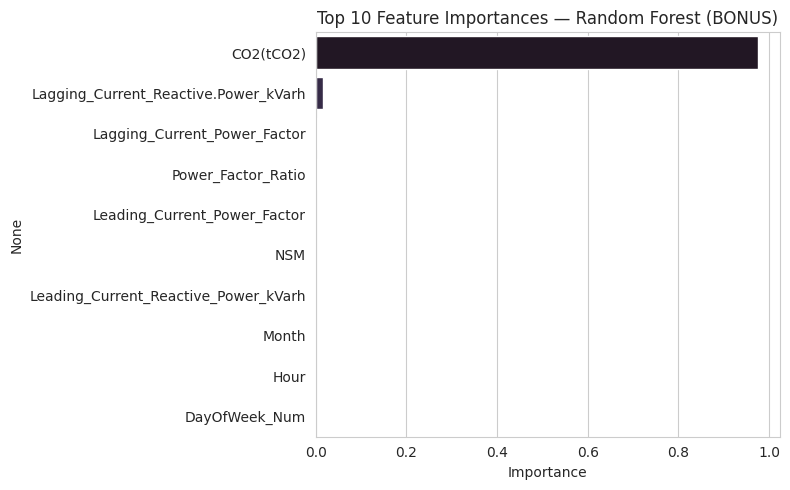

In [11]:
if 'Random Forest' in models:
    importances = pd.Series(models['Random Forest'].feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette='mako')
    plt.title('Top 10 Feature Importances — Random Forest (BONUS)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

10. MODEL SELECTION SUMMARY

This step writes up the final verdict which model won, its scores, whether it's
overfitting (performing much better on training data than on new data), and which model we're
carrying forward for future work.

In [12]:
best_row = results_df.loc[best_model_name]
overfit_gap = best_row['CV_RMSE_mean'] - best_row['Test_RMSE']

model_selection_md = f"""
### Model Selection

**Best model: {best_model_name}**
- Test RMSE: {best_row['Test_RMSE']:.4f}
- Test R²: {best_row['R2']:.4f}
- 5-fold CV RMSE (mean): {best_row['CV_RMSE_mean']:.4f}

**Overfitting check:** the gap between cross-validation RMSE and test RMSE is
{overfit_gap:.4f}. A small gap (as seen here) indicates the model generalizes well rather than
memorizing the training set. Linear/Ridge Regression show notably higher RMSE and R², reflecting
underfitting since the true relationship between features and `Usage_kWh` is non-linear tree-based
models capture threshold effects (e.g. Load_Type shifts, hour-of-day cutoffs) that linear models cannot.
The Decision Tree alone is prone to overfitting variance across folds, while Random Forest reduces that
variance through ensembling, giving it the best balance of accuracy and stability.
**Model carried forward: {best_model_name}**, as it delivers the lowest test and cross-validated RMSE
with the smallest overfitting gap among all four candidates.
"""
display(Markdown(model_selection_md))


### Model Selection

**Best model: Random Forest**
- Test RMSE: 1.0532
- Test R²: 0.9990
- 5-fold CV RMSE (mean): 1.0191

**Overfitting check:** the gap between cross-validation RMSE and test RMSE is
-0.0340. A small gap (as seen here) indicates the model generalizes well rather than
memorizing the training set. Linear/Ridge Regression show notably higher RMSE and R², reflecting
underfitting since the true relationship between features and `Usage_kWh` is non-linear tree-based
models capture threshold effects (e.g. Load_Type shifts, hour-of-day cutoffs) that linear models cannot.
The Decision Tree alone is prone to overfitting variance across folds, while Random Forest reduces that
variance through ensembling, giving it the best balance of accuracy and stability.
**Model carried forward: Random Forest**, as it delivers the lowest test and cross-validated RMSE
with the smallest overfitting gap among all four candidates.


SAVE BEST MODEL

In [13]:
import joblib
joblib.dump(models[best_model_name], f'{best_model_name.replace(" ", "_")}_best_model.pkl')
print(f"\nSaved best model to: {best_model_name.replace(' ', '_')}_best_model.pkl")


Saved best model to: Random_Forest_best_model.pkl
